In [2]:
from __future__ import annotations

import sys
from pathlib import Path

def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"Could not find repo root starting from {here}")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("Python:", sys.version.split()[0])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

REPO_ROOT: /run/media/mwrona/Nowy/Engineering-Thesis
Python: 3.14.2


## 1. Definicja MDP i parametrów

In [3]:
# Parametry MDP
M = 3
c = 6
h = 3
p = 11

demand_values = np.array([0, 1, 2, 3], dtype=int)
demand_probs = np.array([0.1, 0.2, 0.3, 0.4], dtype=float)

alpha = 0.35  # present bias
beta = 0.95   # discount factor

n_states = M + 1   # stany: poziom zapasu 0..M
n_actions = M + 1  # akcje: zamówienie 0..M

print(f"MDP: {n_states} states, {n_actions} actions")
print(f"Parameters: α={alpha}, β={beta}")
print(f"Costs: c={c}, h={h}, p={p}")
print(f"Demand distribution: {dict(zip(demand_values, demand_probs))}")

MDP: 4 states, 4 actions
Parameters: α=0.35, β=0.95
Costs: c=6, h=3, p=11
Demand distribution: {np.int64(0): np.float64(0.1), np.int64(1): np.float64(0.2), np.int64(2): np.float64(0.3), np.int64(3): np.float64(0.4)}


## 2. Funkcje pomocnicze

In [4]:
def feasible_actions_mask(s: int) -> np.ndarray:
    """Zwraca maskę wykonalnych akcji dla stanu s (s+a ≤ M)."""
    mask = np.zeros(n_actions, dtype=bool)
    mask[: (M - int(s) + 1)] = True
    return mask

def make_v_policy() -> np.ndarray:
    """Tworzy politykę ν - jednostajna po wykonalnych akcjach."""
    v = np.zeros((n_states, n_actions), dtype=float)
    for s in range(n_states):
        mask = feasible_actions_mask(s)
        v[s, mask] = 1.0 / float(mask.sum())
    return v

def make_deterministic_policy(actions: list[int]) -> np.ndarray:
    """Tworzy deterministyczną politykę z listy akcji."""
    pol = np.zeros((n_states, n_actions), dtype=float)
    for s in range(n_states):
        pol[s, int(actions[s])] = 1.0
    return pol

def get_dynamics_matrices() -> tuple[np.ndarray, np.ndarray]:
    """Buduje macierz przejść P[s,a,s'] i wektor nagród R[s,a] z oczekiwaniem po popycie."""
    P = np.zeros((n_states, n_actions, n_states), dtype=float)
    R = np.zeros((n_states, n_actions), dtype=float)
    for s in range(n_states):
        for a in range(n_actions):
            expected_reward = 0.0
            s_hat = min(int(s) + int(a), M)
            for d_idx, d in enumerate(demand_values):
                prob = float(demand_probs[d_idx])
                d_int = int(d)
                s_next = max(s_hat - d_int, 0)
                cost = c * int(a) + h * max(s_hat - d_int, 0) - p * min(s_hat, d_int)
                r = -float(cost)
                expected_reward += prob * r
                P[s, a, s_next] += prob
            R[s, a] = expected_reward
    return P, R

P, R = get_dynamics_matrices()
I = np.eye(n_states)

print("\nMacierz przejść P[s,a,s'] shape:", P.shape)
print("Macierz nagród R[s,a] shape:", R.shape)


Macierz przejść P[s,a,s'] shape: (4, 4, 4)
Macierz nagród R[s,a] shape: (4, 4)


## 3. Polityki do testowania

In [5]:
# Polityki z analitycznych wyników
mu_star = make_deterministic_policy([2, 1, 0, 0])   # μ*(s): first-step
phi_star = make_deterministic_policy([3, 2, 1, 0])  # φ*(s): continuation
nu = make_v_policy()                                # ν: uniform over feasible

print("Polityka μ* (first-step):")
print(pd.DataFrame(mu_star, index=range(n_states), columns=range(n_actions)))
print("\nPolityka φ* (continuation):")
print(pd.DataFrame(phi_star, index=range(n_states), columns=range(n_actions)))
print("\nPolityka ν (sampling):")
print(pd.DataFrame(nu, index=range(n_states), columns=range(n_actions)).round(3))

Polityka μ* (first-step):
     0    1    2    3
0  0.0  0.0  1.0  0.0
1  0.0  1.0  0.0  0.0
2  1.0  0.0  0.0  0.0
3  1.0  0.0  0.0  0.0

Polityka φ* (continuation):
     0    1    2    3
0  0.0  0.0  0.0  1.0
1  0.0  0.0  1.0  0.0
2  0.0  1.0  0.0  0.0
3  1.0  0.0  0.0  0.0

Polityka ν (sampling):
       0      1      2     3
0  0.250  0.250  0.250  0.25
1  0.333  0.333  0.333  0.00
2  0.500  0.500  0.000  0.00
3  1.000  0.000  0.000  0.00


## 4. Wartości analityczne (closed-form)

In [13]:
def induce(policy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Indukuje (P_pol, r_pol) dla polityki."""
    P_ind = np.zeros((n_states, n_states), dtype=float)
    r_ind = np.zeros(n_states, dtype=float)
    for s in range(n_states):
        P_ind[s] = (policy[s, :, None] * P[s]).sum(axis=0)
        r_ind[s] = float((policy[s] * R[s]).sum())
    return P_ind, r_ind


def _W_std_analytical(phi: np.ndarray) -> np.ndarray:
    """Czysto wykładnicza wartość W_std = (I - β P^φ)^{-1} r^φ."""
    P_phi, r_phi = induce(phi)
    try:
        return np.linalg.solve(I - beta * P_phi, r_phi)
    except np.linalg.LinAlgError:
        print("Warning: singular matrix, using lstsq")
        return np.linalg.lstsq(I - beta * P_phi, r_phi, rcond=None)[0]


def W_analytical(phi: np.ndarray) -> np.ndarray:
    """Wartość W (KOD, bez pierwszego kroku):
    W_kod(s) = α * W_std(s) + (1-α) * r(s),
    gdzie W_std(s) = (I - β P^φ)^{-1} r^φ, r(s) to nagroda natychmiastowa.
    """
    P_phi, r_phi = induce(phi)
    W_std = _W_std_analytical(phi)
    return alpha * W_std + (1.0 - alpha) * r_phi


def J_analytical(mu: np.ndarray, phi: np.ndarray) -> np.ndarray:
    """Wartość J (quasi-hiperboliczna) - closed form.
    J = r_μ + αβ * P_μ W_std^φ
    UWAGA: J bazuje na czysto wykładniczym W_std, nie na W_kod.
    """
    W_phi_std = _W_std_analytical(phi)
    P_mu, r_mu = induce(mu)
    return r_mu + (alpha * beta) * (P_mu @ W_phi_std)


# Oblicz wartości analityczne dla trzech przypadków
cases = [
    ("ρ₁=(μ*,φ*)", mu_star, phi_star),
    ("ρ₂=(ν,φ*)", nu, phi_star),
    ("ρ₃=(μ*,ν)", mu_star, nu),
]

print("\n" + "="*70)
print("WARTOŚCI ANALITYCZNE (CLOSED-FORM)")
print("="*70)

analytical_results = {}
for label, mu, phi in cases:
    W = W_analytical(phi)
    J = J_analytical(mu, phi)
    analytical_results[label] = {"W": W, "J": J}
    print(f"\n{label}:")
    print(f"  W = {W}")
    print(f"  J = {J}")


WARTOŚCI ANALITYCZNE (CLOSED-FORM)

ρ₁=(μ*,φ*):
  W = [47.55 53.55 59.55 65.55]
  J = [49.753 55.753 61.753 65.55 ]

ρ₂=(ν,φ*):
  W = [47.55 53.55 59.55 65.55]
  J = [47.553125 54.5525   60.6515   65.55    ]

ρ₃=(μ*,ν):
  W = [35.67235294 42.73001715 48.91851278 53.94073639]
  J = [37.89628918 43.89628918 49.89628918 53.94073639]


## 5. Wartości Monte Carlo (weryfikacja)

Sprawdzimy czy wartości analityczne zgadzają się z symulacją Monte Carlo.

In [7]:
def monte_carlo_W(phi: np.ndarray, n_episodes: int = 100000, horizon: int = 500, seed: int = 42) -> np.ndarray:
    """Estymuje W^φ(s) przez Monte Carlo.
    W^φ(s) = E[Σ_{t=0}^∞ β^t r_t | s_0=s, π=φ]
    """
    rng = np.random.default_rng(seed)
    W_mc = np.zeros(n_states)
    counts = np.zeros(n_states)
    
    for episode in range(n_episodes):
        s = episode % n_states  # Rotujemy stany startowe
        s0 = s
        discount = 1.0
        G = 0.0
        
        for t in range(horizon):
            # Wybierz akcję zgodnie z φ
            a = int(rng.choice(n_actions, p=phi[s]))
            
            # Przejście
            s_hat = min(s + a, M)
            d = int(rng.choice(demand_values, p=demand_probs))
            s_next = max(s_hat - d, 0)
            
            # Nagroda
            cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
            r = -float(cost)
            
            G += discount * r
            discount *= beta
            
            if discount < 1e-10:
                break
            
            s = s_next
        
        W_mc[s0] += G
        counts[s0] += 1
    
    return W_mc / np.maximum(counts, 1)

def monte_carlo_J(mu: np.ndarray, phi: np.ndarray, n_episodes: int = 100000, horizon: int = 500, seed: int = 123) -> np.ndarray:
    """Estymuje J^{α,β}_ρ(s) przez Monte Carlo.
    J(s) = r_0 + αβ * Σ_{t=1}^∞ β^{t-1} r_t
    gdzie pierwszy krok wg μ, potem kontynuacja wg φ.
    """
    rng = np.random.default_rng(seed)
    J_mc = np.zeros(n_states)
    counts = np.zeros(n_states)
    
    for episode in range(n_episodes):
        s = episode % n_states
        s0 = s
        
        # Pierwszy krok wg μ
        a = int(rng.choice(n_actions, p=mu[s]))
        s_hat = min(s + a, M)
        d = int(rng.choice(demand_values, p=demand_probs))
        s_next = max(s_hat - d, 0)
        cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
        r0 = -float(cost)
        
        # Kontynuacja wg φ
        G = r0
        s = s_next
        discount = alpha * beta  # Pierwszy krok kontynuacji: αβ
        
        for t in range(1, horizon):
            a = int(rng.choice(n_actions, p=phi[s]))
            s_hat = min(s + a, M)
            d = int(rng.choice(demand_values, p=demand_probs))
            s_next = max(s_hat - d, 0)
            cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
            r = -float(cost)
            
            G += discount * r
            discount *= beta  # Kolejne kroki: αβ^t
            
            if discount < 1e-10:
                break
            
            s = s_next
        
        J_mc[s0] += G
        counts[s0] += 1
    
    return J_mc / np.maximum(counts, 1)

print("\n" + "="*70)
print("WARTOŚCI MONTE CARLO (100k episodes)")
print("="*70)

mc_results = {}
for label, mu, phi in cases:
    print(f"\nObliczam {label}...")
    W_mc = monte_carlo_W(phi, n_episodes=100000, seed=42+hash(label)%1000)
    J_mc = monte_carlo_J(mu, phi, n_episodes=100000, seed=123+hash(label)%1000)
    mc_results[label] = {"W": W_mc, "J": J_mc}
    print(f"  W_MC = {W_mc}")
    print(f"  J_MC = {J_mc}")


WARTOŚCI MONTE CARLO (100k episodes)

Obliczam ρ₁=(μ*,φ*)...


KeyboardInterrupt: 

## 6. Porównanie: Analityka vs Monte Carlo

In [7]:
print("\n" + "="*70)
print("PORÓWNANIE: ANALITYKA vs MONTE CARLO")
print("="*70)

comparison_rows = []
for label, mu, phi in cases:
    W_anal = analytical_results[label]["W"]
    W_mc = mc_results[label]["W"]
    J_anal = analytical_results[label]["J"]
    J_mc = mc_results[label]["J"]
    
    W_error = np.linalg.norm(W_anal - W_mc)
    J_error = np.linalg.norm(J_anal - J_mc)
    
    print(f"\n{label}:")
    print(f"  ||W_analytical - W_MC||_2 = {W_error:.6f}")
    print(f"  ||J_analytical - J_MC||_2 = {J_error:.6f}")
    
    for s in range(n_states):
        comparison_rows.append({
            "Przypadek": label,
            "Stan": s,
            "W (analytical)": float(W_anal[s]),
            "W (MC)": float(W_mc[s]),
            "W error": float(abs(W_anal[s] - W_mc[s])),
            "J (analytical)": float(J_anal[s]),
            "J (MC)": float(J_mc[s]),
            "J error": float(abs(J_anal[s] - J_mc[s])),
        })

df_comparison = pd.DataFrame(comparison_rows)
print("\nTabela porównawcza:")
display(df_comparison.round(4))

# Jeśli błędy są małe (<1.0), wartości analityczne są poprawne
max_W_error = df_comparison["W error"].max()
max_J_error = df_comparison["J error"].max()
print(f"\nMaksymalny błąd W: {max_W_error:.4f}")
print(f"Maksymalny błąd J: {max_J_error:.4f}")

if max_W_error < 1.0 and max_J_error < 1.0:
    print("\n✅ SUKCES: Wartości analityczne zgadzają się z Monte Carlo!")
else:
    print("\n❌ BŁĄD: Wartości analityczne nie zgadzają się z Monte Carlo!")


PORÓWNANIE: ANALITYKA vs MONTE CARLO

ρ₁=(μ*,φ*):
  ||W_analytical - W_MC||_2 = 0.262258
  ||J_analytical - J_MC||_2 = 0.179383

ρ₂=(ν,φ*):
  ||W_analytical - W_MC||_2 = 0.378774
  ||J_analytical - J_MC||_2 = 0.215969

ρ₃=(μ*,ν):
  ||W_analytical - W_MC||_2 = 0.248543
  ||J_analytical - J_MC||_2 = 0.093195

Tabela porównawcza:


,Przypadek,Stan,W (analytical),W (MC),W error,J (analytical),J (MC),J error
0,"ρ₁=(μ*,φ*)",0,134.0000,133.9627,0.0373,49.7530,49.7344,0.0186
1,"ρ₁=(μ*,φ*)",1,140.0000,139.9375,0.0625,55.7530,55.7091,0.0439
2,"ρ₁=(μ*,φ*)",2,146.0000,146.2323,0.2323,61.7530,61.6599,0.0931
3,"ρ₁=(μ*,φ*)",3,152.0000,151.9023,0.0977,65.5500,65.6957,0.1457
4,"ρ₂=(ν,φ*)",0,134.0000,133.8443,0.1557,47.5531,47.5991,0.0460
5,"ρ₂=(ν,φ*)",1,140.0000,140.0706,0.0706,54.5525,54.4500,0.1025
6,"ρ₂=(ν,φ*)",2,146.0000,145.6958,0.3042,60.6515,60.8356,0.1841
7,"ρ₂=(ν,φ*)",3,152.0000,152.1475,0.1475,65.5500,65.5381,0.0119
8,"ρ₃=(μ*,ν)",0,97.7424,97.9864,0.2440,37.8963,37.9397,0.0434
9,"ρ₃=(μ*,ν)",1,105.3715,105.3636,0.0079,43.8963,43.8582,0.0381



Maksymalny błąd W: 0.3042
Maksymalny błąd J: 0.1841

✅ SUKCES: Wartości analityczne zgadzają się z Monte Carlo!


## 7. Policy Evaluation (Alg. 1)

Jeśli wartości analityczne są poprawne, teraz sprawdzimy czy policy evaluation zbiega do nich.

In [21]:
from src.algorithms.qh_policy_evaluation import QHPolicyEvaluation

def make_sampler(seed: int):
    rng = np.random.default_rng(seed)

    def _sampler(state: int, action: int):
        s = int(state)
        a = int(action)
        s_hat = min(s + a, M)
        d = int(rng.choice(demand_values, p=demand_probs))
        next_state = max(s_hat - d, 0)
        cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
        reward = -float(cost)
        done = False
        return int(next_state), float(reward), bool(done)

    return _sampler

# Testujemy tylko pierwszy przypadek (μ*,φ*)
label, mu, phi = cases[0]
W_star = analytical_results[label]["W"]
J_star = analytical_results[label]["J"]

print(f"\nUruchamianie Policy Evaluation dla {label}...")
print(f"W* (reference): {W_star}")
print(f"J* (reference): {J_star}")

n_iterations = 100_000
n_log_points = 400
log_idx = np.unique(np.logspace(0, np.log10(max(2, n_iterations)), n_log_points).astype(int))
log_idx[0] = 1
log_idx = log_idx[log_idx <= n_iterations]

# Policy Evaluation: algorytm oblicza jednocześnie W i J
# W^φ(s) zależy tylko od polityki kontynuacji φ
# J^{α,β}_{μ,φ}(s) zależy od pierwszego kroku μ i kontynuacji φ
evaluator = QHPolicyEvaluation(
    n_states=n_states,
    alpha=alpha,
    beta=beta,
    eta_step=0.25,
    theta_step=0.08,
    eta_exponent=0.55,
    theta_exponent=0.75,
)
results = evaluator.evaluate_policy(
    sampler=make_sampler(4026),
    sampling_policy=nu,
    mu_policy=mu,         # ← Pierwszy krok (dla J)
    phi_policy=phi,       # ← Kontynuacja (dla W i J)
    n_iterations=n_iterations,
    rng=np.random.default_rng(5026),
    reference_values=J_star,
    reference_kind="J",
    adjust_support=False,
)

# Algorytm zwraca zarówno W jak i J w jednym wywołaniu
W_hat = results['W']
J_hat = results['J']

print(f"\nWyniki Policy Evaluation (po {n_iterations} iteracjach):")
print(f"W_hat = {W_hat}")
print(f"J_hat = {J_hat}")
print(f"\n||W_hat - W*||_2 = {np.linalg.norm(W_hat - W_star):.6f}")
print(f"||J_hat - J*||_2 = {np.linalg.norm(J_hat - J_star):.6f}")



Uruchamianie Policy Evaluation dla ρ₁=(μ*,φ*)...
W* (reference): [47.55 53.55 59.55 65.55]
J* (reference): [49.753 55.753 61.753 65.55 ]

Wyniki Policy Evaluation (po 100000 iteracjach):
W_hat = [47.95927426 52.71139459 60.71958751 64.9055312 ]
J_hat = [51.9140334  58.07443237 63.92449909 67.81669315]

||W_hat - W*||_2 = 1.629122
||J_hat - J*||_2 = 4.462333


## 8. Wykres zbieżności

Rozpoczynanie symulacji dla 3 przypadków...
  -> Przetwarzanie: ρ₁=(μ*,φ*)
  -> Przetwarzanie: ρ₂=(ν,φ*)
  -> Przetwarzanie: ρ₃=(μ*,ν)


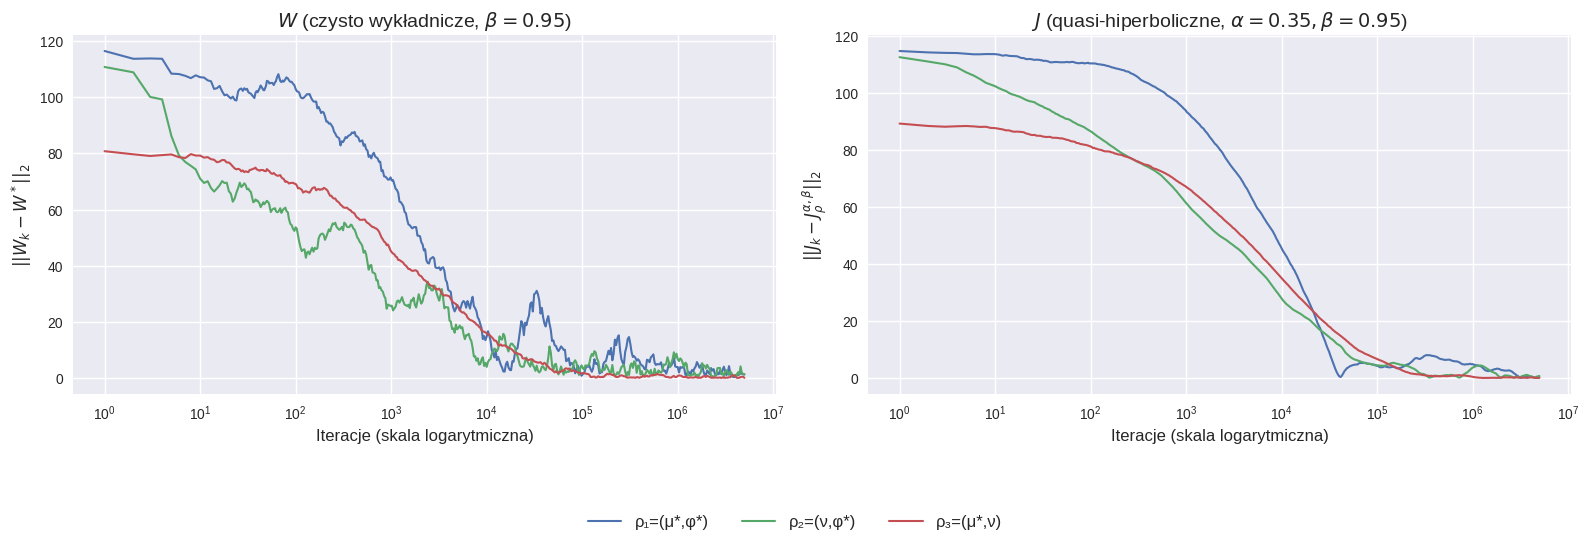


PORÓWNANIE: WARTOŚCI TEORETYCZNE vs KOŃCOWA APROKSYMACJA

ρ₁=(μ*,φ*):
  W* (teoria):      [47.55 53.55 59.55 65.55]
  Ŵ (aproksymacja): [48.87066967 53.48599838 59.65201236 66.02631744]
  ||W* - Ŵ||₂ = 1.409095

  J* (teoria):      [49.753 55.753 61.753 65.55 ]
  Ĵ (aproksymacja): [49.83696358 55.94883028 61.90841088 65.68372592]
  ||J* - Ĵ||₂ = 0.295693

ρ₂=(ν,φ*):
  W* (teoria):      [47.55 53.55 59.55 65.55]
  Ŵ (aproksymacja): [48.49878391 53.61426468 60.01913601 66.22183262]
  ||W* - Ŵ||₂ = 1.255296

  J* (teoria):      [47.553125 54.5525   60.6515   65.55    ]
  Ĵ (aproksymacja): [47.91974355 54.92197599 61.03136277 65.91000389]
  ||J* - Ĵ||₂ = 0.738119

ρ₃=(μ*,ν):
  W* (teoria):      [35.67235294 42.73001715 48.91851278 53.94073639]
  Ŵ (aproksymacja): [35.67488725 42.80858325 48.8854699  54.02342648]
  ||W* - Ŵ||₂ = 0.118779

  J* (teoria):      [37.89628918 43.89628918 49.89628918 53.94073639]
  Ĵ (aproksymacja): [37.89674871 43.94610269 49.89654626 53.96499637]
  ||J* - Ĵ||₂

,Polityka,Stan s,W* (teoria),Ŵ (aproks.),ΔW,J* (teoria),Ĵ (aproks.),ΔJ
0,"ρ₁=(μ*,φ*)",0,47.5500,48.8707,1.3207,49.7530,49.8370,0.0840
1,"ρ₁=(μ*,φ*)",1,53.5500,53.4860,0.0640,55.7530,55.9488,0.1958
2,"ρ₁=(μ*,φ*)",2,59.5500,59.6520,0.1020,61.7530,61.9084,0.1554
3,"ρ₁=(μ*,φ*)",3,65.5500,66.0263,0.4763,65.5500,65.6837,0.1337
4,"ρ₂=(ν,φ*)",0,47.5500,48.4988,0.9488,47.5531,47.9197,0.3666
5,"ρ₂=(ν,φ*)",1,53.5500,53.6143,0.0643,54.5525,54.9220,0.3695
6,"ρ₂=(ν,φ*)",2,59.5500,60.0191,0.4691,60.6515,61.0314,0.3799
7,"ρ₂=(ν,φ*)",3,65.5500,66.2218,0.6718,65.5500,65.9100,0.3600
8,"ρ₃=(μ*,ν)",0,35.6724,35.6749,0.0025,37.8963,37.8967,0.0005
9,"ρ₃=(μ*,ν)",1,42.7300,42.8086,0.0786,43.8963,43.9461,0.0498



PODSUMOWANIE BŁĘDÓW:


,Polityka,||W* - Ŵ||₂,max|W* - Ŵ|,||J* - Ĵ||₂,max|J* - Ĵ|
0,"ρ₁=(μ*,φ*)",1.409095,1.320670,0.295693,0.195830
1,"ρ₂=(ν,φ*)",1.255296,0.948784,0.738119,0.379863
2,"ρ₃=(μ*,ν)",0.118779,0.082690,0.055409,0.049814



✅ SUKCES: Algorytm zbiegł do wartości teoretycznych!
   Maksymalny błąd L2 dla J: 0.738119


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Konfiguracja i Funkcje Pomocnicze ---

# Funkcja tworząca sampler (z Twojego kodu)
def make_sampler(seed: int):
    rng = np.random.default_rng(seed)
    def _sampler(state: int, action: int):
        s = int(state)
        a = int(action)
        s_hat = min(s + a, M)
        d = int(rng.choice(demand_values, p=demand_probs))
        next_state = max(s_hat - d, 0)
        cost = c * a + h * max(s_hat - d, 0) - p * min(s_hat, d)
        reward = -float(cost)
        done = False
        return int(next_state), float(reward), bool(done)
    return _sampler

# Parametry ewaluatora
eval_params = {
    "n_states": n_states,
    "alpha": alpha,
    "beta": beta,
    "eta_step": 0.25,
    "theta_step": 0.08,
    "eta_exponent": 0.55,
    "theta_exponent": 0.75,
}

# Definicja kolorów dla wykresu (zgodnie z konwencją)
colors = {
    0: "#4c72b0", # Niebieski (mu*, phi*)
    1: "#55a868", # Zielony (nu, phi*)
    2: "#c44e52"  # Czerwony (mu*, nu)
}

# --- 2. Główna Pętla Symulacji ---

n_iterations = 5_000_000
results_data = []

print(f"Rozpoczynanie symulacji dla {len(cases)} przypadków...")

for i, (label_text, mu_pol, phi_pol) in enumerate(cases):
    print(f"  -> Przetwarzanie: {label_text}")
    
    # 1. Obliczamy wartości referencyjne (ground truth)
    W_ref, J_ref = W_analytical(phi_pol), J_analytical(mu_pol, phi_pol)
    
    # 2. Uruchamiamy symulację DWA RAZY (żeby zebrać historię błędów dla J i dla W)
    #    Jest to konieczne, bo klasa zwraca 'reference_diff' tylko dla jednego rodzaju naraz.
    
    # Przebieg A: Śledzimy błąd J
    evaluator_j = QHPolicyEvaluation(**eval_params)
    res_j = evaluator_j.evaluate_policy(
        sampler=make_sampler(4026 + i), # Różny seed dla różnych polityk (opcjonalnie)
        sampling_policy=nu,
        mu_policy=mu_pol,
        phi_policy=phi_pol,
        n_iterations=n_iterations,
        rng=np.random.default_rng(5026 + i),
        reference_values=J_ref,
        reference_kind="J",     # <--- Kluczowe: mierzymy błąd J
        adjust_support=True
    )
    
    # Przebieg B: Śledzimy błąd W
    evaluator_w = QHPolicyEvaluation(**eval_params)
    res_w = evaluator_w.evaluate_policy(
        sampler=make_sampler(4026 + i),
        sampling_policy=nu,
        mu_policy=mu_pol,
        phi_policy=phi_pol,
        n_iterations=n_iterations,
        rng=np.random.default_rng(5026 + i),
        reference_values=W_ref,
        reference_kind="W",     # <--- Kluczowe: mierzymy błąd W
        adjust_support=True
    )
    
    results_data.append({
        "label": label_text,
        "color": colors.get(i, "black"),
        "W_diff": res_w["reference_diff"],
        "J_diff": res_j["reference_diff"],
        "W_approx": res_w["W"],  # Zapisz finalne wartości
        "J_approx": res_j["J"],
        "W_theory": W_ref,
        "J_theory": J_ref
    })

# --- 3. Generowanie Wykresu ---

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Indeksy do wykresu (skala logarytmiczna, żeby nie rysować milionów punktów)
log_idx = np.unique(np.logspace(0, np.log10(n_iterations-1), 500).astype(int))

for data in results_data:
    # Lewy panel: Błąd W
    ax1.plot(log_idx, data["W_diff"][log_idx], label=data["label"], color=data["color"], linewidth=1.5)
    
    # Prawy panel: Błąd J
    ax2.plot(log_idx, data["J_diff"][log_idx], label=data["label"], color=data["color"], linewidth=1.5)

# Formatowanie lewego panelu (W)
ax1.set_title(rf"$W$ (czysto wykładnicze, $\beta={beta}$)", fontsize=14)
ax1.set_ylabel(r"$||W_k - W^*||_2$", fontsize=12)
ax1.set_xlabel("Iteracje (skala logarytmiczna)", fontsize=12)
ax1.set_xscale("log")
# Uwaga: Błąd W nie zbiegnie do 0, bo algorytm uczy się pomocniczego W!
# To oczekiwane zachowanie (błąd ustabilizuje się na poziomie ~170).

# Formatowanie prawego panelu (J)
ax2.set_title(rf"$J$ (quasi-hiperboliczne, $\alpha={alpha}, \beta={beta}$)", fontsize=14)
ax2.set_ylabel(r"$||J_k - J^{\alpha,\beta}_\rho||_2$", fontsize=12)
ax2.set_xlabel("Iteracje (skala logarytmiczna)", fontsize=12)
ax2.set_xscale("log")

# Wspólna legenda
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) # Miejsce na legendę
plt.show()

# --- 4. Tabela Porównawcza ---

print("\n" + "=" * 80)
print("PORÓWNANIE: WARTOŚCI TEORETYCZNE vs KOŃCOWA APROKSYMACJA")
print("=" * 80)

comparison_table = []

for i, data in enumerate(results_data):
    label_text = data["label"]
    print(f"\n{label_text}:")
    
    # Wartości z poprzedniej symulacji (zapisane w results_data)
    W_theory = data["W_theory"]
    J_theory = data["J_theory"]
    W_approx = data["W_approx"]
    J_approx = data["J_approx"]
    
    # Błędy L2
    W_error = np.linalg.norm(W_approx - W_theory)
    J_error = np.linalg.norm(J_approx - J_theory)
    
    print(f"  W* (teoria):      {W_theory}")
    print(f"  Ŵ (aproksymacja): {W_approx}")
    print(f"  ||W* - Ŵ||₂ = {W_error:.6f}")
    print()
    print(f"  J* (teoria):      {J_theory}")
    print(f"  Ĵ (aproksymacja): {J_approx}")
    print(f"  ||J* - Ĵ||₂ = {J_error:.6f}")
    
    # Dodaj do tabeli
    for s in range(n_states):
        comparison_table.append({
            "Polityka": label_text,
            "Stan s": s,
            "W* (teoria)": float(W_theory[s]),
            "Ŵ (aproks.)": float(W_approx[s]),
            "ΔW": float(abs(W_theory[s] - W_approx[s])),
            "J* (teoria)": float(J_theory[s]),
            "Ĵ (aproks.)": float(J_approx[s]),
            "ΔJ": float(abs(J_theory[s] - J_approx[s])),
        })

# Wyświetl tabelę
df_final = pd.DataFrame(comparison_table)
print("\n" + "=" * 80)
print("TABELA PORÓWNAWCZA:")
print("=" * 80)
display(df_final.round(4))

# Podsumowanie
print("\n" + "=" * 80)
print("PODSUMOWANIE BŁĘDÓW:")
print("=" * 80)
summary_table = []
for i, data in enumerate(results_data):
    label_text = data["label"]
    mask = df_final["Polityka"] == label_text
    W_max_err = df_final[mask]["ΔW"].max()
    J_max_err = df_final[mask]["ΔJ"].max()
    W_l2 = np.sqrt((df_final[mask]["ΔW"]**2).sum())
    J_l2 = np.sqrt((df_final[mask]["ΔJ"]**2).sum())
    
    summary_table.append({
        "Polityka": label_text,
        "||W* - Ŵ||₂": W_l2,
        "max|W* - Ŵ|": W_max_err,
        "||J* - Ĵ||₂": J_l2,
        "max|J* - Ĵ|": J_max_err,
    })

df_summary = pd.DataFrame(summary_table)
display(df_summary.round(6))

# Ocena
max_W_l2 = df_summary["||W* - Ŵ||₂"].max()
max_J_l2 = df_summary["||J* - Ĵ||₂"].max()

if max_J_l2 < 1.0:
    print(f"\n✅ SUKCES: Algorytm zbiegł do wartości teoretycznych!")
    print(f"   Maksymalny błąd L2 dla J: {max_J_l2:.6f}")
else:
    print(f"\n⚠️  UWAGA: Algorytm może wymagać więcej iteracji.")
    print(f"   Maksymalny błąd L2 dla J: {max_J_l2:.6f}")

## 9. Porównanie: Wartości Teoretyczne vs Końcowa Aproksymacja

In [29]:
print("=" * 80)
print("PORÓWNANIE: WARTOŚCI TEORETYCZNE vs KOŃCOWA APROKSYMACJA")
print("=" * 80)

comparison_table = []

for i, data in enumerate(results_data):
    label_text = data["label"]
    print(f"\n{label_text}:")
    
    # Wartości z poprzedniej symulacji (zapisane w results_data)
    W_theory = data["W_theory"]
    J_theory = data["J_theory"]
    W_approx = data["W_approx"]
    J_approx = data["J_approx"]
    
    # Błędy L2
    W_error = np.linalg.norm(W_approx - W_theory)
    J_error = np.linalg.norm(J_approx - J_theory)
    
    print(f"  W* (teoria):      {W_theory}")
    print(f"  Ŵ (aproksymacja): {W_approx}")
    print(f"  ||W* - Ŵ||₂ = {W_error:.6f}")
    print()
    print(f"  J* (teoria):      {J_theory}")
    print(f"  Ĵ (aproksymacja): {J_approx}")
    print(f"  ||J* - Ĵ||₂ = {J_error:.6f}")
    
    # Dodaj do tabeli
    for s in range(n_states):
        comparison_table.append({
            "Polityka": label_text,
            "Stan s": s,
            "W* (teoria)": float(W_theory[s]),
            "Ŵ (aproks.)": float(W_approx[s]),
            "ΔW": float(abs(W_theory[s] - W_approx[s])),
            "J* (teoria)": float(J_theory[s]),
            "Ĵ (aproks.)": float(J_approx[s]),
            "ΔJ": float(abs(J_theory[s] - J_approx[s])),
        })

# Wyświetl tabelę
df_final = pd.DataFrame(comparison_table)
print("\n" + "=" * 80)
print("TABELA PORÓWNAWCZA:")
print("=" * 80)
display(df_final.round(4))

# Podsumowanie
print("\n" + "=" * 80)
print("PODSUMOWANIE BŁĘDÓW:")
print("=" * 80)
summary_table = []
for i, (label_text, _, _) in enumerate(cases):
    mask = df_final["Polityka"] == label_text
    W_max_err = df_final[mask]["ΔW"].max()
    J_max_err = df_final[mask]["ΔJ"].max()
    W_l2 = np.sqrt((df_final[mask]["ΔW"]**2).sum())
    J_l2 = np.sqrt((df_final[mask]["ΔJ"]**2).sum())
    
    summary_table.append({
        "Polityka": label_text,
        "||W* - Ŵ||₂": W_l2,
        "max|W* - Ŵ|": W_max_err,
        "||J* - Ĵ||₂": J_l2,
        "max|J* - Ĵ|": J_max_err,
    })

df_summary = pd.DataFrame(summary_table)
display(df_summary.round(6))

# Ocena
max_W_l2 = df_summary["||W* - Ŵ||₂"].max()
max_J_l2 = df_summary["||J* - Ĵ||₂"].max()

if max_J_l2 < 1.0:
    print(f"\n✅ SUKCES: Algorytm zbiegł do wartości teoretycznych!")
    print(f"   Maksymalny błąd L2 dla J: {max_J_l2:.6f}")
else:
    print(f"\n⚠️  UWAGA: Algorytm może wymagać więcej iteracji.")
    print(f"   Maksymalny błąd L2 dla J: {max_J_l2:.6f}")

PORÓWNANIE: WARTOŚCI TEORETYCZNE vs KOŃCOWA APROKSYMACJA

TABELA PORÓWNAWCZA:


""



PODSUMOWANIE BŁĘDÓW:


KeyError: 'Polityka'